In [ ]:
%load_ext autoreload
%autoreload 2

fig_num = 5 # change this to the figure number
analysis_name = "hpc_TEMPLATE" # change this to the subfolder it should save to

subject = "Wallie"
date = "20220912"
nwb_file_name = f"{subject}{date}_.nwb"
epoch_interval = "10_lineartrack"
key = {"nwb_file_name": nwb_file_name,}

from spyglass.common import PositionIntervalMap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
pos_interval = (PositionIntervalMap() &{**key, "interval_list_name": epoch_interval}).fetch1("position_interval_name")

In [57]:
from spyglass.decoding.v1.c3po import Model

# model_key = {**key, "model_name":"wallie_linear_dim20_noSmooth_v0"}

model_key = {**key, 'model_name': 'wallie_linear_dim20_10Smooth_v0'}


analysis = (Model & model_key).fetch_c3po_analysis(checkpoint = None)
analysis.fit_context_pca()
t_interp = np.arange(analysis.t[0], analysis.t[-1], 0.001)
analysis.interpolate_context(t_interp)
analysis.embed_context_pca()

from c3po.analysis.analysis import figure_directory
from pathlib import Path
fig_dir = Path(figure_directory) / f"Fig{fig_num}/{analysis_name}"/f"{subject}_{date}_{epoch_interval}_{model_key['model_name']}"
fig_dir.mkdir(parents=True, exist_ok=True)

[15:21:07][WARNING] Spyglass: Restriction had no effect — no shared attributes found. Please check your restrict() call.
[15:21:07][WARNING] Spyglass: Restriction had no effect — no shared attributes found. Please check your restrict() call.
[15:21:07][WARNING] Spyglass: Restriction had no effect — no shared attributes found. Please check your restrict() call.


x shape (1, 5)


/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  overri

# Load data

### position

In [ ]:
from utils.load_hpc_data import load_position_data

pos_data = load_position_data(nwb_file_name, epoch_interval)

pos_df = pos_data["pos_df"]
pos_times = pos_data["pos_times"]
pos = pos_data["pos"]
vel = pos_data["vel"]
all_running_intervals = pos_data["all_running_intervals"]
left_running_intervals = pos_data["left_running_intervals"]
right_running_intervals = pos_data["right_running_intervals"]


### LFP

In [33]:
from utils.load_hpc_data import load_lfp_data

lfp_data = load_lfp_data(nwb_file_name, epoch_interval)
theta_phase_df = lfp_data["theta_phase_df"]
fg_phase_df = lfp_data["fg_phase_df"]
sg_phase_df = lfp_data["sg_phase_df"]


### SortedData

In [ ]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup

spikes_key = {
    **key,
    "sorted_spikes_group_name": epoch_interval,
}
SortedSpikesGroup() & spikes_key
spikes_list, unit_ids = (SortedSpikesGroup() & spikes_key).fetch_spike_data(
    spikes_key, return_unit_ids=True
)

### Ripples

In [12]:
from spyglass.ripple.v1 import RippleTimesV1, RippleLFPSelection

ripple_df = (
    RippleTimesV1()
    & key
    & f"target_interval_list_name LIKE '%{pos_interval}%'"
).fetch1_dataframe()
ripple_intervals = ripple_df[["start_time", "end_time"]].values

### DIO Behavior Marks

In [ ]:
from spyglass.common import DIOEvents

event_types = ["poke", "reward"]
behavior_evenets = {}
for dio in event_types:
    dio_query = DIOEvents() & key & f"dio_event_name LIKE '%{dio}%'"
    marks = []
    for nwb in dio_query.fetch_nwb():
        obj = nwb["dio"]
        t = obj.timestamps[:]
        data = obj.data[:]
        marks.extend(t[data == 1])
    marks = np.array(marks)
    behavior_evenets[dio] = marks

# Analyze

In [66]:
analysis.fit_context_pca(fit_intervals=all_running_intervals)
analysis.embed_context_pca()

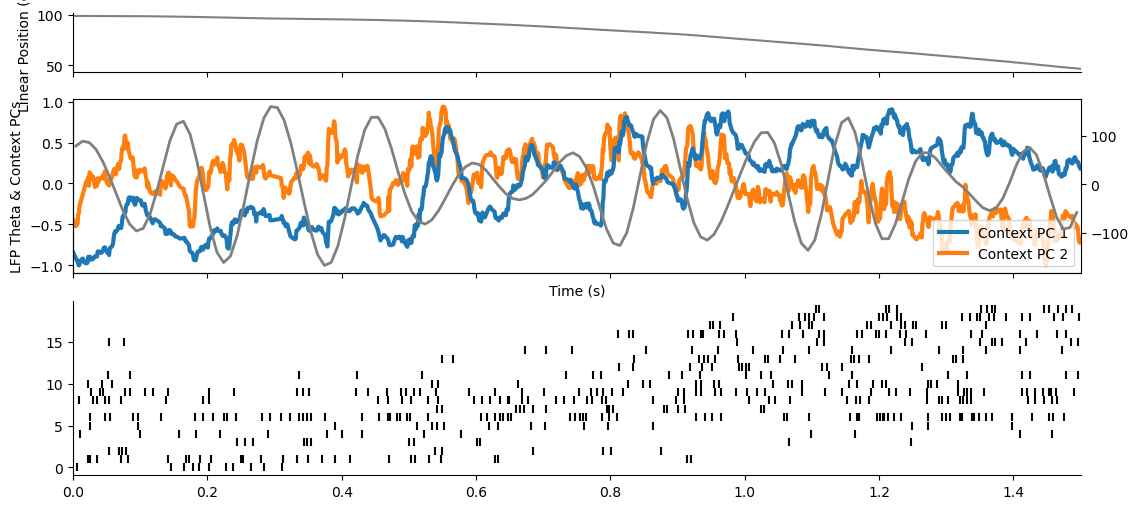

In [68]:
# analysis = analysis_all

i = 30
# t_rng = 2,5
# t_rng = 2.5, 3.5

# i = 5
# t_rng = -1, 2
# t_rng = 1.6, 2.6
# t_rng = 3, 6
# t_rng = 3.5, 5

i = 5
t_rng = -1, 2
t_rng = 1.6, 2.6
t_rng = 3, 6
t_rng = 3.5, 5

smooth_width = 51

pc_inds = np.array([0, 1])
# t_rng = 3,4

fig, ax = plt.subplots(
    nrows=3,
    sharex=True,
    height_ratios=[1, 3, 3],
    figsize=(13, 6),
)

# ax = ax_list[1:]

interval = [i_ for i_ in left_running_intervals if i_[1] - i_[0] > 0.5]
interval = interval[i]
st = left_running_intervals[i][0] + t_rng[0]
en = left_running_intervals[i][0] + t_rng[1]

t_theta = theta_phase_df.index
ind_theta = np.logical_and(
    t_theta >= st,
    t_theta <= en,
)
theta_ax = ax[1].twinx()
theta_ax.plot(
    t_theta[ind_theta] - st,
    theta_phase_df["signal"].values[ind_theta],
    c="grey",
    lw=2,
    zorder=-10,
    label="LFP Theta Band",
)

ind_context = np.logical_and(
    analysis.t_interp >= st,
    analysis.t_interp <= en,
)
c_plot = analysis.c_pca_interp[ind_context][:, pc_inds]
if len(c_plot.shape) == 1:
    c_plot = c_plot[:, None]

# c_plot = gaussian_filter1d(c_plot, smooth_width, axis=0, mode="nearest")
c_plot = c_plot - np.mean(c_plot, axis=0)
c_plot = c_plot / (np.max(np.abs(c_plot), axis=0))
for j in range(2):
    ax[1].plot(
        analysis.t_interp[ind_context] - st,
        c_plot[:, j],
        zorder=1 - j,
        label=f"Context PC {j+1}",
        lw=3,
    )
    # break


pos_ind = np.logical_and(
    pos_df.index >= st,
    pos_df.index <= en,
)
ax[0].plot(
    pos_df.index[pos_ind] - st,
    pos_df.linear_position[pos_ind],
    c="gray",
    # s=5,
    zorder=-5,
)
# plt.xlim(4,5)
# plt.xlim(2,3)
# ind_theta = np.logical_and(
#     phase_df.index >= left_running_intervals[i][0], phase_df.index <= left_running_intervals[i][0] +dur,
# )
# plt.plot(phase_df.index[ind_theta], phase_df["electrode 12"].values[ind_theta])

ind_theta = np.logical_and(
    theta_phase_df.index >= st,
    theta_phase_df.index <= en,
)
# plt.plot(
#     phase_df.index[ind_theta] - st,
#     phase_df["phase"].values[ind_theta],
# )

ax[1].legend(loc="lower right")
for a in ax:
    a.spines[["top", "right"]].set_visible(False)

ax[1].set_xlabel("Time (s)")
ax[0].set_ylabel("Linear Position (cm)")
ax[1].set_ylabel("LFP Theta & Context PCs")
plt.xlim(0, t_rng[1] - t_rng[0])


min_spikes = 10
plot_spikes = []
for s in spikes_list:
    s_st = np.digitize(st, s)
    s_en = np.digitize(en, s)
    if s_en - s_st < min_spikes:
        continue
    plot_spikes.append(s[s_st:s_en])

order = np.argsort([np.mean(s) for s in plot_spikes])
plot_spikes = [plot_spikes[i] for i in order]
for i, s in enumerate(plot_spikes):
    ax[2].scatter(s - st, np.ones(len(s)) * i, marker="|", color="k")

In [60]:
pos_bins = np.linspace(10, 110, 50)
pca = True
analysis_ = analysis#_running

left_binned_context, bins = analysis_.bin_context_by_feature(
    pos_df.linear_position.values,
    pos_df.index,
    pca=pca,
    valid_intervals=left_running_intervals,
    bins=pos_bins,
    # interpolated=True,
)

right_binned_context, bins = analysis_.bin_context_by_feature(
    pos_df.linear_position.values,
    pos_df.index,
    pca=pca,
    valid_intervals=right_running_intervals,
    bins=pos_bins,
    # interpolated=True,
)

mid_list = []
lo_list = []
hi_list = []

for j, binned_context in enumerate([left_binned_context, right_binned_context]):
    mid = np.array([np.nanmedian(b, axis=0) for b in binned_context])
    hi = np.array(
        [
            np.nanpercentile(
                b,
                75,
                axis=0,
            )
            for b in binned_context
        ]
    )
    lo = np.array(
        [
            np.nanpercentile(
                b,
                25,
                axis=0,
            )
            for b in binned_context
        ]
    )
    mid_list.append(mid)
    lo_list.append(lo)
    hi_list.append(hi)

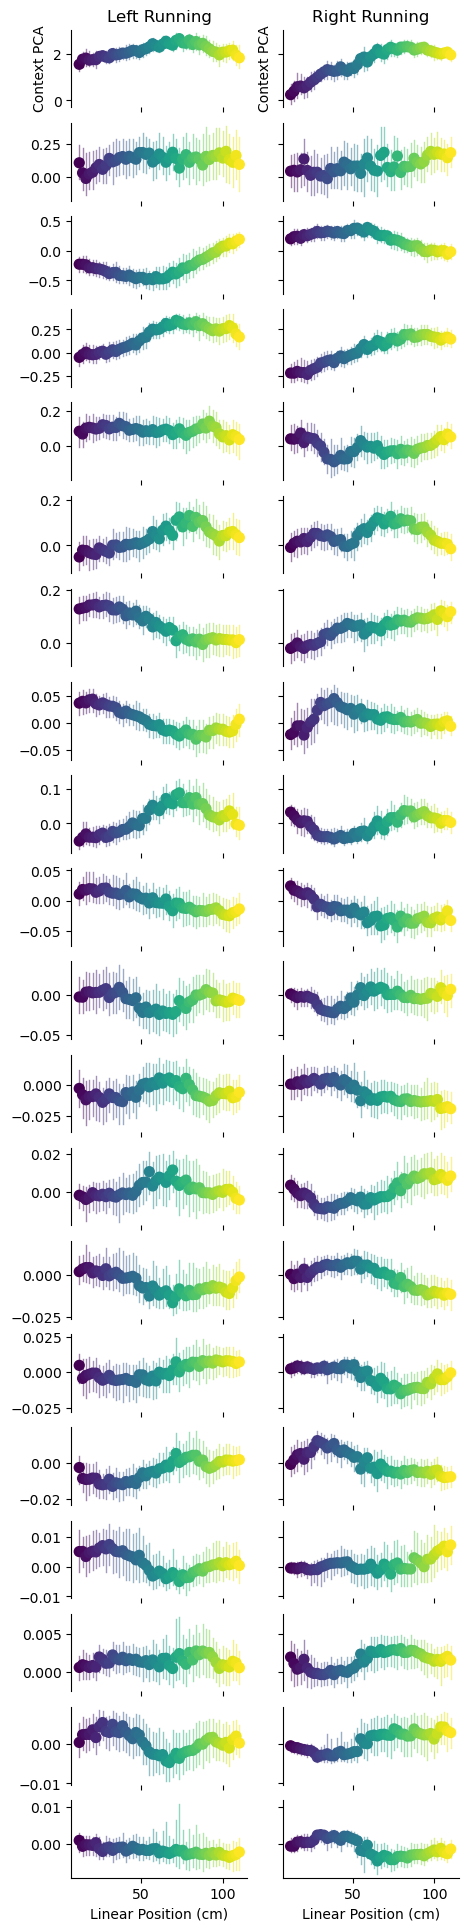

In [62]:
n_plot = 20
n_plot = min(analysis.context_dim, n_plot)

fig, ax_list = plt.subplots(
    nrows=n_plot, ncols=2, sharex=True, sharey="row", figsize=(5, 1.2 * n_plot)
)
for j, name in enumerate(["Left", "Right"]):
    ax = ax_list[:, j]
    mid = mid_list[j]
    lo = lo_list[j]
    hi = hi_list[j]
    c = np.linspace(0, 1, mid.shape[0])
    for i, a in enumerate(ax):
        a.scatter(bins[1:], mid[:, i], s=50, c=c)
        # a.vlines(bins[1:], lo[:, i], hi[:, i], alpha=0.5, zorder=-1)
        for k in range(len(bins[1:])):
            a.plot(
                [bins[k + 1], bins[k + 1]],
                [lo[k, i], hi[k, i]],
                alpha=0.5,
                zorder=-1,
                c=plt.cm.viridis(c[k]),
                lw=1,
            )
        a.spines[["top", "right", "bottom"]].set_visible(False)
    ax[-1].spines["bottom"].set_visible(True)

    ax[-1].set_xlabel("Linear Position (cm)")
    ax[0].set_title(f"{name} Running")
    ax[0].set_ylabel("Context PCA")

In [72]:
n_pos = 100
n_theta = 50

n_pos = 30
n_theta = 15

# n_pos = 150
# n_theta = 75

left_binned_context, b1, b2, counts_left = analysis.bin_context_by_feature_2d(
    pos_df.linear_position.values,
    pos_df.index,
    theta_phase_df.phase.values,
    theta_phase_df.index,
    pca=True,
    interpolated=True,
    valid_intervals=left_running_intervals,
    bins_1=np.linspace(10, 110, n_pos),
    bins_2=np.linspace(0, 2 * np.pi - 0.01, n_theta),
    return_counts=True,
)


right_binned_context, b1, b2, counts_right = analysis.bin_context_by_feature_2d(
    pos_df.linear_position.values,
    pos_df.index,
    theta_phase_df.phase.values,
    theta_phase_df.index,
    pca=True,
    interpolated=True,
    valid_intervals=right_running_intervals,
    bins_1=np.linspace(10, 110, n_pos),
    bins_2=np.linspace(0.01, 2 * np.pi - 0.01, n_theta),
    return_counts=True,
)

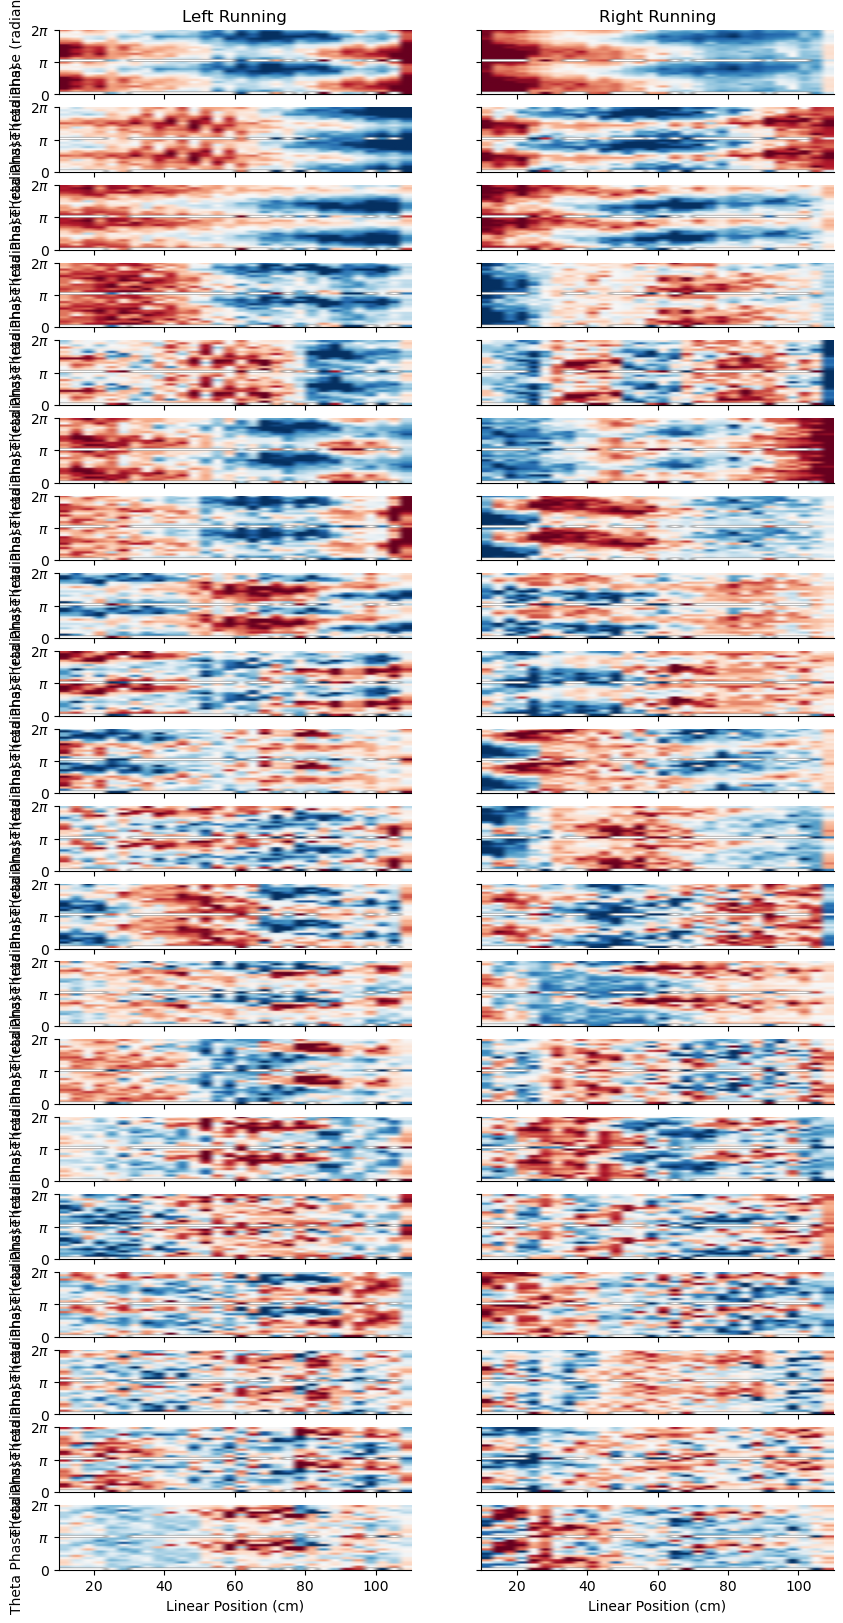

In [73]:
n_plot = 20

mid_left = np.array(
    [
        [
            np.nanmean(b, axis=0) if len(b) else np.nan * np.zeros(analysis.context_dim)
            for b in row
        ]
        for row in left_binned_context
    ]
)
mid_right = np.array(
    [
        [
            np.nanmean(b, axis=0) if len(b) else np.nan * np.zeros(analysis.context_dim)
            for b in row
        ]
        for row in right_binned_context
    ]
)
mid.shape
fig, ax_list = plt.subplots(
    nrows=min(analysis.context_dim, n_plot),
    sharex=True,
    sharey=True,
    figsize=(10, n_plot * 1),
    ncols=2,
)


for j, (name, data) in enumerate(zip(["Left", "Right"], [mid_left, mid_right])):
    ax = ax_list[:, j]
    ax[0].set_title(f"{name} Running")
    for i, a in enumerate(ax):
        val = data[:, :, i].T
        val = val - np.nanmean(val)
        val = val / np.nanpercentile(np.abs(val), 97)
        # val = np.roll(val, val.shape[0] // 2, axis=0)
        val = np.concatenate(
            [
                val,
                val,
            ],
            axis=0,
        )
        a.imshow(
            val,
            cmap="RdBu",
            extent=[b1[0], b1[-1], b2[0], b2[-1]],
            aspect="auto",
            clim=(-0.9, 0.9),
        )
        a.spines[
            [
                "top",
                "right",
            ]
        ].set_visible(False)

for a in ax_list[-1]:
    a.spines["bottom"].set_visible(True)
    a.set_xlabel("Linear Position (cm)")
for a in ax_list[:, 0]:
    a.set_ylabel("Theta Phase (radians)")
    # a.set_yticks(
    #     np.linspace(0, 2 * np.pi, 3),
    #     [r"-$\pi$", "0", r"$\pi$"],
    # )
    a.set_yticks(
        np.linspace(0, 2 * np.pi, 3),
        ["0", r"$\pi$", r"$2\pi$"],
    )

# plt.imshow(mid[:,:,1].T,cmap='RdBu',extent=[b1[0],b1[-1],b2[0],b2[-1]],aspect='auto')
# plt.colorbar()

NameError: name 'figure_folder' is not defined

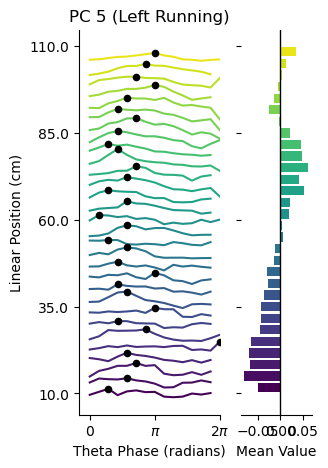

In [76]:
pc = 5
data = mid_left

# fig = plt.figure(figsize=(2, 5))

fig, ax = plt.subplots(figsize=(3, 5), ncols=2, width_ratios=[2, 1], sharey=True)

val = data[:, :, pc].T

scale_factor = 0
for i in range(val.shape[-1]):
    val_i = val[:, i].copy()
    mid_i = np.nanmean(val_i)
    val_i = val_i - np.nanmean(val_i)
    scale_i = np.nanpercentile(np.abs(val_i), 97)
    if scale_i > scale_factor:
        scale_factor = scale_i


for i in range(val.shape[-1]):
    val_i = val[:, i].copy()
    mid_i = np.nanmean(val_i)

    val_i = val_i - np.nanmean(val_i)
    val_i = val_i / scale_factor
    # val_i = val_i / np.nanpercentile(np.abs(val_i), 97)
    # val_i = val_i / np.nanpercentile(np.abs(val), 97) *3

    ax[0].plot(b2[:], val_i + i * 1, c=plt.cm.viridis(i / val.shape[-1]))
    ind_max = np.nanargmax(val[:, i])
    ax[0].scatter(b2[ind_max], val_i[ind_max] + i * 1, c="k", s=20, zorder=50)

    ax[1].barh(i + 0.5, mid_i, color=plt.cm.viridis(i / val.shape[-1]))
    # ind_min = np.nanargmin(val[:, i])
    # plt.scatter(b2[ind_min], val_i[ind_min] + i * 1, c='r', s=100, zorder=50)

ax[0].set_xticks(
    np.linspace(0, 2 * np.pi, 3),
    ["0", r"$\pi$", r"$2\pi$"],
)
ax[0].set_yticks(
    np.linspace(0, val.shape[-1] * 1, 5),
    np.linspace(b1[0], b1[-1], 5),
)
ax[0].set_xlabel("Theta Phase (radians)")
ax[0].set_ylabel("Linear Position (cm)")
ax[0].set_title(f"PC {pc} (Left Running)")

for a in ax:
    a.spines[["top", "right"]].set_visible(False)
ax[0].set_xlim(-0.5, 2 * np.pi)


ax[1].spines["left"].set_visible(False)
ax[1].axvline(0, c="k", ls="-", lw=1)
# ax[1].set_xticks(
#     [-2, 0, 2],
# )
ax[1].set_xlabel("Mean Value")

fig.savefig(
    figure_folder / f"contextPCA_thetaPhase_position_PC{pc}_leftRunning.svg",
)

In [ ]:
#

In [69]:
import sortingview.views as vv
import os
from matplotlib.colors import to_hex

os.environ["KACHERY_API_KEY"] = "g9UmADRrAGfSPs1RRNKd6DtYTao3WQd2"


color_list = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
]

subsample = 3
context_graph = vv.TimeseriesGraph()

c_fig = analysis.c_pca
# c_fig = smooth(c_fig, sigma=int(10), hamming=True)
c_fig = c_fig[::subsample]
t_fig = analysis.t[::subsample]

# c_fig = analysis.c_pca_interp[::subsample]
# t_fig = analysis.t_interp[::subsample]

ind = ~np.any(np.isnan(c_fig), axis=1)
c_fig = c_fig[ind]
t_fig = t_fig[ind]


for i in np.arange(
    3,
):
    context_graph.add_line_series(
        name=f"context pc: {i}",
        t=t_fig,
        y=c_fig[:, i].astype(np.float32),
        width=2,
        color=color_list[i],
    )


context_graph2 = vv.TimeseriesGraph()
for i in np.arange(3, 7):
    context_graph2.add_line_series(
        name=f"context pc: {i}",
        t=t_fig,
        y=c_fig[:, i].astype(np.float32),
        width=2,
        color=color_list[i],
    )


# Speed graph
speed_graph = vv.TimeseriesGraph()
# for angle in trials_df.reach_angle.unique():
#     angle_df = trials_df[trials_df.reach_angle == angle]
#     print(angle_df.size)
#     color = to_hex(plt.cm.hsv((angle + np.pi) / (2 * np.pi)))
#     intervals_ = angle_df.target_on_time.values
#     # intervals_ = [[i, i+.5] for i in intervals_]
#     speed_graph.add_interval_series(
#         name=f"{angle} cue",
#         t_start=intervals_,
#         t_end=intervals_ + 0.05,
#         color=color,
#     )

#     intervals_ = angle_df.go_cue_time.values
#     # intervals_ = [[i, i+.5] for i in intervals_]
#     speed_graph.add_interval_series(
#         name=f"{angle} go",
#         t_start=intervals_,
#         t_end=intervals_ + 1,
#         color=color,
#     )

speed_graph.add_line_series(
    name="lin_pos",
    t=pos_df.index.values,
    y=pos_df.linear_position.values.astype(np.float32),
    color=color_list[0],
    width=2,
)
# speed_graph.add_line_series(
#     name="vel_y",
#     t=behavior_df.index.values,
#     y=behavior_df.hand_vel_y.values.astype(np.float32),
#     color=color_list[1],
#     width=2,
# )

# mua_graph = vv.TimeseriesGraph()
# mua_graph.add_line_series(
#     name="mua",
#     t=pos_df.index.values,
#     y=mua.astype(np.float32),
#     color=color_list[2],
#     width=2,
# )


# ASSEMBLE
context_panels = [
    vv.LayoutItem(speed_graph, stretch=1),

    # vv.LayoutItem(lfp_graph, stretch=1),
    # vv.LayoutItem(mua_graph, stretch=1),
    vv.LayoutItem(context_graph, stretch=3),
    vv.LayoutItem(context_graph2, stretch=3),
]

view = vv.Box(
    direction="horizontal",
    show_titles=True,
    height=8,
    items=[
        vv.LayoutItem(
            vv.Box(
                direction="vertical",
                show_titles=True,
                items=context_panels,
            )
        ),
    ],
)
# view.url(label=f"wallie_linear_smooth")

'https://figurl.org/f?v=npm://@fi-sci/figurl-sortingview@12/dist&d=kachery:franklab.default:sha1:b2a3529cab9ec29f8e66324538ab634886c91d73&label=wallie_linear_smooth&zone=franklab.default'

In [48]:
model_key["model_name"]

'wallie_linear_dim20_noSmooth_v0'